# DL Foundations: Convolutional Neural Networks in CV. Part 1.

# Bacis: Основные строительные блоки

## 1. Recap: Свертки

Хотим обработать изображение размером 256x256.

1. Сколько нам это будет стоить с помощью Fully-Сonnectеd Layers?
2. Если мы объект видели только в левом правом углу, сможем ли мы его опознать по центру?

### 1. Convolution layers

![conv.png](assets/conv.png)

$$ Y_{h,w,j}=\sum_{i=1}^{C}\sum_{u=1}^{k}\sum_{v=1}^{k}X_{h+u,\,w+v,\,i}\;\cdot\;K_{u,v,i,j}$$

- Вместо $𝐻 \cdot 𝑊 \cdot 𝐶 \cdot 𝐶_{𝑜𝑢𝑡}$ параметров $𝑘 \cdot 𝑘 \cdot 𝐶 \cdot 𝐶_{𝑜𝑢𝑡}$
- Закладывают правильные геометрические предположения о данных:
  - Объекты локальны
  - Могут смещаться
  - Могут меняться в масштабе
  - Могут поворачиваться


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy import typing as npt

%matplotlib inline

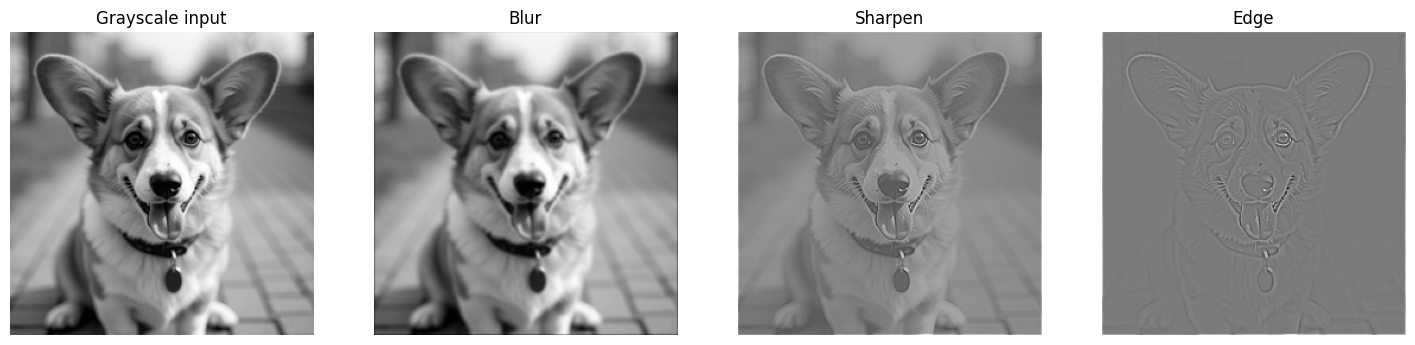

In [2]:
def normalize(img: torch.Tensor) -> npt.NDArray[np.float32]:
    """Нормализация тензора в диапазон [0, 1] для визуализации"""
    arr = img.detach().cpu().numpy()
    minv, maxv = arr.min(), arr.max()
    if maxv - minv < 1e-6:
        return np.zeros_like(arr)
    return (arr - minv) / (maxv - minv)


def show_row(
    images: list[npt.NDArray],
    titles: list[str],
    figsize: tuple[int, int] = (18, 5),
    gray: bool = False
) -> None:
    """Отображение набора изображений в одну строку"""
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if gray:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis("off")
    plt.show()


# загрузка изображения
image = Image.open("assets/corgi.png").resize((256, 256))
image_gray = image.convert("L")
tensor_gray = torch.tensor(
    np.asarray(image_gray),
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)  / 255.0   # (1, 1, H, W)


# разные фильтры

blur = torch.tensor([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=torch.float32) / 9

sharpen = torch.tensor([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=torch.float32)

edge = torch.tensor([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=torch.float32)

filters = [blur, sharpen, edge]

# применяем по очереди и сохраняем
res = []
conv = nn.Conv2d(1, 1, 3, padding=1, bias=False)
for i in range(3):
    conv.weight.data = filters[i].unsqueeze(0).unsqueeze(0)
    res.append(conv(tensor_gray))

# визуализируем
show_row(
    images=[image_gray] + [normalize(res[i][0][0]) for i in range(3)],
    titles=[
        "Grayscale input",
        "Blur",
        "Sharpen",
        "Edge"
    ],
    gray=True
)

### 2. Depthwise Convolutions

![image.png](assets/dw.png)


**Отдельная свёртка для каждого канала**

Допустим, у входа:

- размер: `H × W × C` (C каналов)

**Формула**
$$Y_{h,w,i} =\sum_{u=1}^{k}\sum_{v=1}^{k}X_{h+u,\,w+v,\,i}\;\cdot\;K_{u,v,i}$$

В **depthwise convolution**:

- берётся **C разных фильтров**
- каждый фильтр размера `k × k`
- **каждый фильтр применяется только к своему каналу**
- нет взаимодействия между каналами
- нет «комбинации признаков»
- улучшает каждый признак по отдельности
- не у меет в «если есть это и это вместе — значит объект такой»


А что, если мы хотим, чтобы $C_{in} \neq C_{out}$ ?


**чистый depthwise conv не умеет менять число каналов**.

Чтобы получить $C_{out}$, делают **второй шаг**.

_______________

### 3. Pointwise Convolution (1×1)
![dw_sep.png](assets/dw_sep.png)

Теперь у нас:

- вход: `H × W × C` (C каналов)
- выход: `H × W × C_out` ($C_{out} \neq C$)

**Формула**

$$Y_{h,w,j}=\sum_{i=1}^{C}X_{h,w,i}\;\cdot\;w_{i,j}$$

Это **смешивание каналов без spatial-изменений**

**Параметры**

$$C \cdot C_{out}$$
_______________


### 4. Depthwise Separable Convolution

**Шаг 1 (пространство):**

$$Z_{h,w,i}
=\sum_{u,v}X_{h+u,w+v,i} \cdot K_{u,v,i}$$

**Шаг 2 (каналы):**

$$Y_{h,w,j}=\sum_{i=1}^{C}Z_{h,w,i} \cdot w_{i,j}$$


**Сравнение c обычной сверткой**

$$\underbrace{k^2 \cdot C \cdot C_{out}}_{\text{обычная conv}}
\quad\text{vs}\quad
\underbrace{k^2 \cdot C + C \cdot C_{out}}_{\text{depthwise + 1×1}}$$

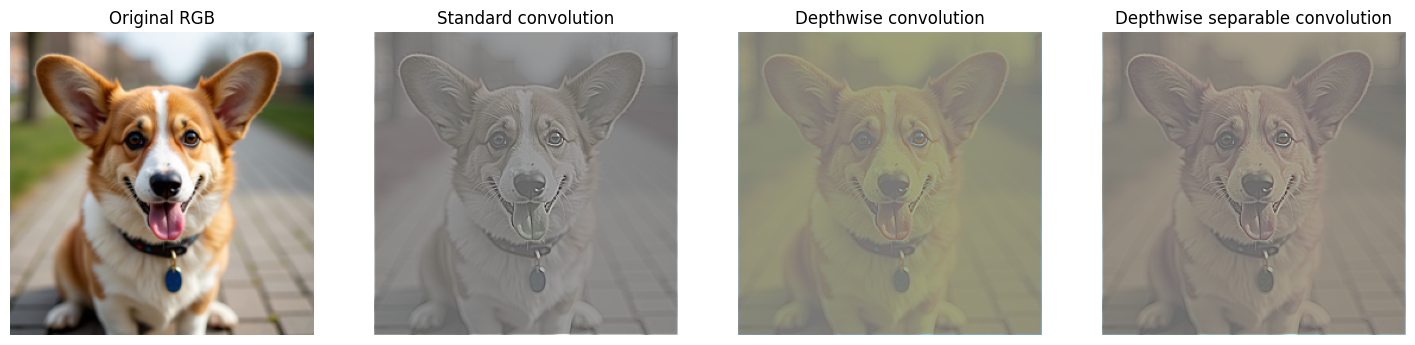

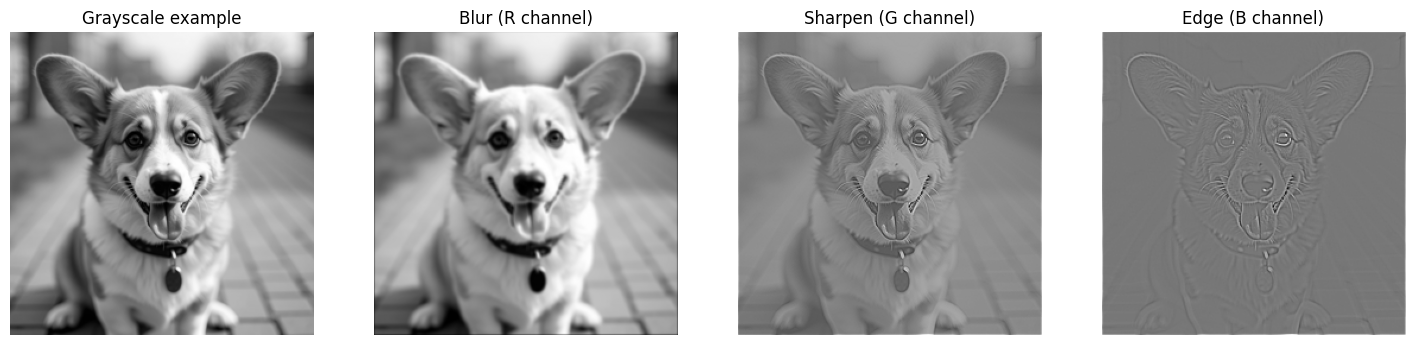

In [7]:
# делаем RGB-input
tensor_rgb = torch.tensor(
    np.transpose(np.asarray(image), (2, 0, 1)),
    dtype=torch.float32
).unsqueeze(0) / 255.0   # (1, 3, H, W)


# Standard convolution (смешивание каналов)
std = nn.Conv2d(3, 3, 3, padding=1, bias=False)
W = torch.zeros((3, 3, 3, 3))

for out_c in range(3):
    for in_c in range(3):
        W[out_c, in_c] = filters[(out_c + in_c) % 3]

std.weight.data = W
y_std = std(tensor_rgb)


# Depthwise convolution (каналы независимы)
dw = nn.Conv2d(3, 3, 3, padding=1, groups=3, bias=False)
dw.weight.data = torch.stack(filters).unsqueeze(1)
y_dw = dw(tensor_rgb)


# Depthwise separable convolution (depthwise + 1x1)
pw = nn.Conv2d(3, 3, 1, bias=False)

pw.weight.data = torch.tensor([
    [[[1.0]], [[0.5]], [[0.2]]],
    [[[0.2]], [[1.0]], [[0.5]]],
    [[[0.5]], [[0.2]], [[1.0]]],
], dtype=torch.float32)

y_sep = pw(dw(tensor_rgb))


# визуализация RGB-сравнения
std_vis = np.transpose(normalize(y_std[0]), (1, 2, 0))
dw_vis  = np.transpose(normalize(y_dw[0]),  (1, 2, 0))
sep_vis = np.transpose(normalize(y_sep[0]), (1, 2, 0))

show_row(
    images=[image, std_vis, dw_vis, sep_vis],
    titles=[
        "Original RGB",
        "Standard convolution",
        "Depthwise convolution",
        "Depthwise separable convolution"
    ]
)


# визуализация работы отдельных фильтров в DepthWise
show_row(
    images=[image_gray] + [normalize(y_dw[0, i, :, :]) for i in range(3)],
    titles=[
        "Grayscale example",
        "Blur (R channel)",
        "Sharpen (G channel)",
        "Edge (B channel)"
    ],
    gray=True
)


#### 5. Groupwise Convolution (Grouped Conv)

![grouped.png](assets/grouped.png)

- Вход:

$$X \in \mathbb{R}^{H \times W \times C} $$ 

- Нужно получить:

$$Y \in \mathbb{R}^{H' \times W' \times C_{out}} $$ 

- Число групп:

$$G \;\;(\;G \mid C \;\text{и}\; G \mid C_{out}\;)$$ 


**Ключевая идея**

- Каналы **разбиваются на группы**
- Свёртка происходит **только внутри группы**
- **Между группами смешивания нет**

    - Входных каналов в группе:
    
    $$C_{in}^{(g)} = \frac{C}{G}$$ 
    
    - Выходных каналов в группе:
    
    $$C_{out}^{(g)} = \frac{C_{out}}{G}$$ 


**Формула**

Для группы g = 1..G

и выходного канала jjj внутри этой группы:

$$Y^{(g)}_{h,w,j} = \sum_{i=1}^{C/G} \sum_{u,v} X^{(g)}_{h+u,w+v,i} \cdot K^{(g)}_{u,v,i,j}$$ 

где:

- $X^{(g)}$— каналы входа, *принадлежащие группе g*
- $K^{(g)}$ — фильтры *только для этой группы*

**Число параметров**

$$
k^2 \cdot \frac{C_{\text{in}}}{G} \cdot \frac{C_{\text{out}}}{G} \cdot G
\;=\;
k^2 \cdot \frac{C_{\text{in}} \cdot C_{\text{out}}}{G}
$$


**Частные случаи**

-  G=1 - Обычная свёртка

$$ k^2 \cdot C \cdot C_{out}$$ 

- G=C - Depthwise convolution

$$ k^2 \cdot C$$ 


In [4]:
# НЕ СРАБОТАЕТ

G = 2

# Groupwise convolution (частичное смешивание)
grp = nn.Conv2d(3, 3, 3, padding=1, groups=G, bias=False)
W_grp = torch.zeros((3, 3 // G, 3, 3))

# группа 1: каналы 0–1
W_grp[0, 0] = blur
W_grp[0, 1] = sharpen
W_grp[1, 0] = sharpen
W_grp[1, 1] = edge

# группа 2: канал 2
W_grp[2, 0] = edge

grp.weight.data = W_grp
y_grp = grp(tensor_rgb)


# визуализация
grp_vis = np.transpose(normalize(y_grp[0]), (1, 2, 0))

show_row(
    images=[image, std_vis, grp_vis, dw_vis],
    titles=[
        "Original RGB",
        "Standard convolution (full mixing)",
        "Groupwise convolution (partial mixing)",
        "Depthwise convolution (no mixing)"
    ]
)

ValueError: in_channels must be divisible by groups

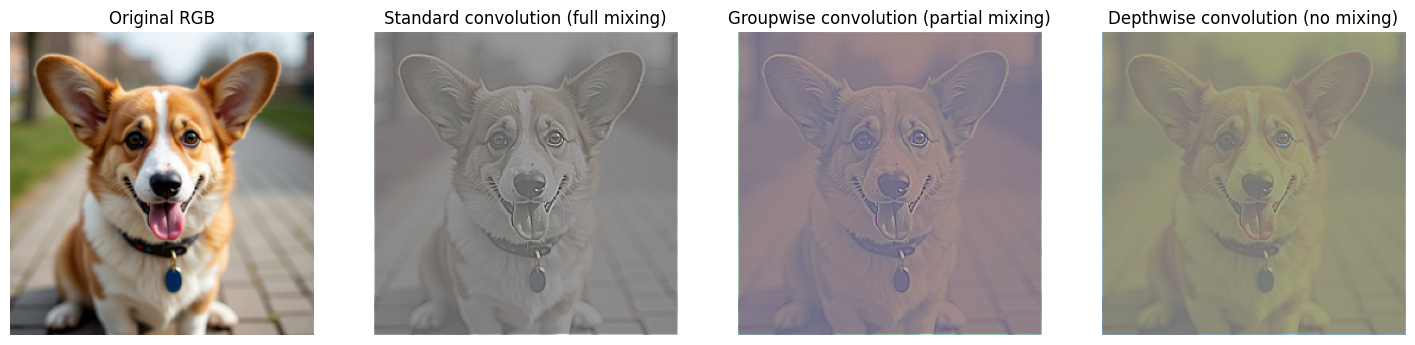

In [8]:
G = 2   # 2 группы по 2 канала

# сделаем 4-канальное изображение, иначе ValueError: in_channels must be divisible by groups
alpha = torch.ones_like(tensor_rgb[:, :1, :, :])    # (1, 1, H, W)
tensor_rgba = torch.cat([tensor_rgb, alpha], dim=1)   # (1,4,H,W)

grp = nn.Conv2d(
    in_channels=4,
    out_channels=4,
    kernel_size=3,
    padding=1,
    groups=G,
    bias=False
)

W_grp = torch.zeros((4, 4 // G, 3, 3))

# группа 1: R,G
W_grp[0, 0] = blur
W_grp[0, 1] = sharpen
W_grp[1, 0] = sharpen
W_grp[1, 1] = edge

# группа 2: B,A
W_grp[2, 0] = edge
W_grp[2, 1] = blur
W_grp[3, 0] = blur
W_grp[3, 1] = sharpen

grp.weight.data = W_grp
y_grp = grp(tensor_rgba)[:, :3, :, :]

# визуализация
grp_vis = np.transpose(normalize(y_grp[0]), (1, 2, 0))

show_row(
    images=[image, std_vis, grp_vis, dw_vis],
    titles=[
        "Original RGB",
        "Standard convolution (full mixing)",
        "Groupwise convolution (partial mixing)",
        "Depthwise convolution (no mixing)"
    ]
)

### 6. Atrous (Dilated) Convolution
![dilated1.png](assets/dilated.png)

- Вход: $X \in \mathbb{R}^{H \times W \times C}$

- Ядро: $k \times k$

- Коэффициент дилатации: $d \ge 1$


**Идея**

- Между элементами ядра появляются **пропуски**
- Ядро «растягивается» в пространстве
- **Receptive field увеличивается**
- **Число параметров не меняется**

**Формула**

Для выходного канала j:

$$Y_{h,w,j} = \sum_{i=1}^{C} \sum_{u=1}^{k} \sum_{v=1}^{k} X_{h + d\cdot u,\; w + d\cdot v,\; i} \cdot K_{u,v,i,j} $$

Отличие от обычной conv — множитель **d** внутри индексов.

**Receptive Field**

Эффективный размер ядра:

$k_{eff} = k + (k-1)(d-1)$

Пример:

- k=3, d=1 → 3×3
- k=3, d=2 → 5×5
- k=3, d=3 → 7×7

**Параметры**

$k^2 \cdot C \cdot C_{out}$

**! Не зависит от d**

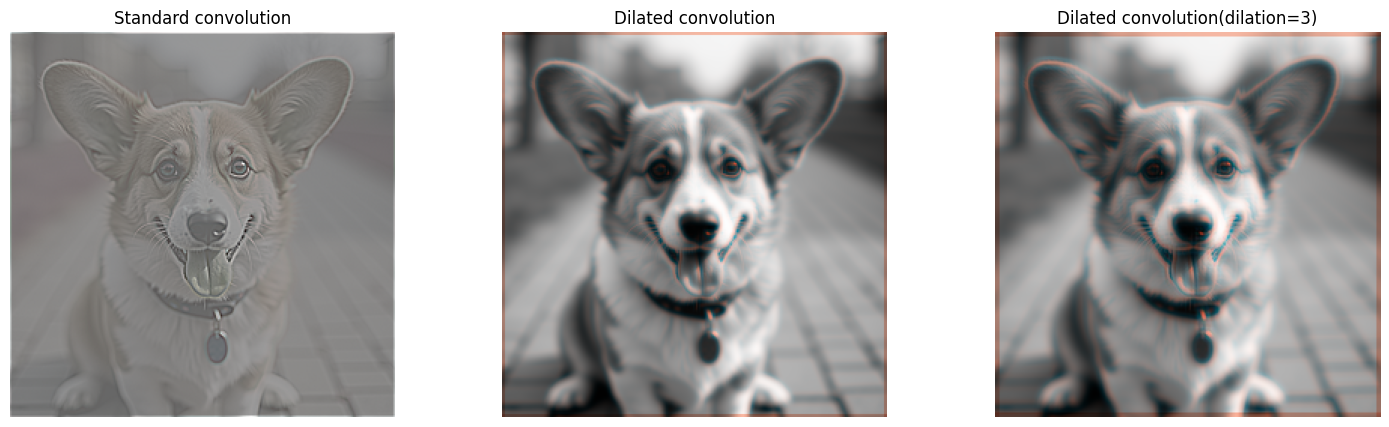

In [9]:
# Сделаем фильтры чуть "мягче", чтобы видеть хорошо разницу
identity = torch.tensor([
    [0,0,0],
    [0,1,0],
    [0,0,0]
], dtype=torch.float32)

soft_blur = torch.tensor([
    [1,2,1],
    [2,4,2],
    [1,2,1]
], dtype=torch.float32)/16

blur = torch.tensor([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=torch.float32)/9

filters_trans = [identity, soft_blur, blur]
filters_trans = torch.stack(filters_trans).unsqueeze(1).repeat(1,3,1,1) 

# Standard convolution
std = nn.Conv2d(3, 3, 3, padding=1, bias=False)
std.weight.data = filters_trans
y_std = std(tensor_rgb)

# Dilated convolution (dilation = 2)
dilated_conv = nn.Conv2d(3, 3, kernel_size=3, padding=2, dilation=2, bias=False)
dilated_conv.weight.data = std.weight.data
y_dlt = dilated_conv(tensor_rgb)
dlt_vis = np.transpose(normalize(y_dlt[0]), (1, 2, 0))

# Dilated convolution (dilation = 23
dilated_conv_3 = nn.Conv2d(3, 3, kernel_size=3, padding=3, dilation=3, stride=1, bias=False)
dilated_conv_3.weight.data = std.weight.data
y_dlt_3 = dilated_conv_3(tensor_rgb)
dlt_3_vis = np.transpose(normalize(y_dlt_3[0]), (1, 2, 0))

# визуализация
show_row(
    images=[std_vis, dlt_vis, dlt_3_vis],
    titles=[
        "Standard convolution",
        "Dilated convolution",
        "Dilated convolution(dilation=3)",
        ""
    ]
)

### 7 .Transposed Convolution (Deconvolution)

![transposed.png](assets/transposed.png)

- Вход: $X \in \mathbb{R}^{H \times W \times C}$
- Выход: $Y \in \mathbb{R}^{H' \times W' \times C_{out}}, \quad H' > H,\; W' > W$


**Идея: Transposed convolution увеличивает spatial-размеры feature map**:

Это не обратная свёртка математически, а **обучаемый upsampling-слой**.
- из маленькой карты → большую
- с *обучаемыми параметрами*

**Как это работает**

1. Берём входную feature map
2. **Вставляем нули** между элементами (upsampling)
3. Применяем обычную свёртку

Операция соответствует транспонированной матрице свёртки

- обычная conv: $Y = K * X$
- transposed conv: $X \approx K^T * Y$

**Параметры**

Те же, что у обычной conv:

$$ k^2 \cdot C \cdot C_{out}$$

**Возможная проблема: checkerboard artifacts**

- неравномерное перекрытие ядер
- stride > 1

$\Longrightarrow$ «шахматные» артефакты на изображении

**Альтернатива: Upsample + Conv**

1. Upsampling (nearest/bilinear)
2. Обычная conv

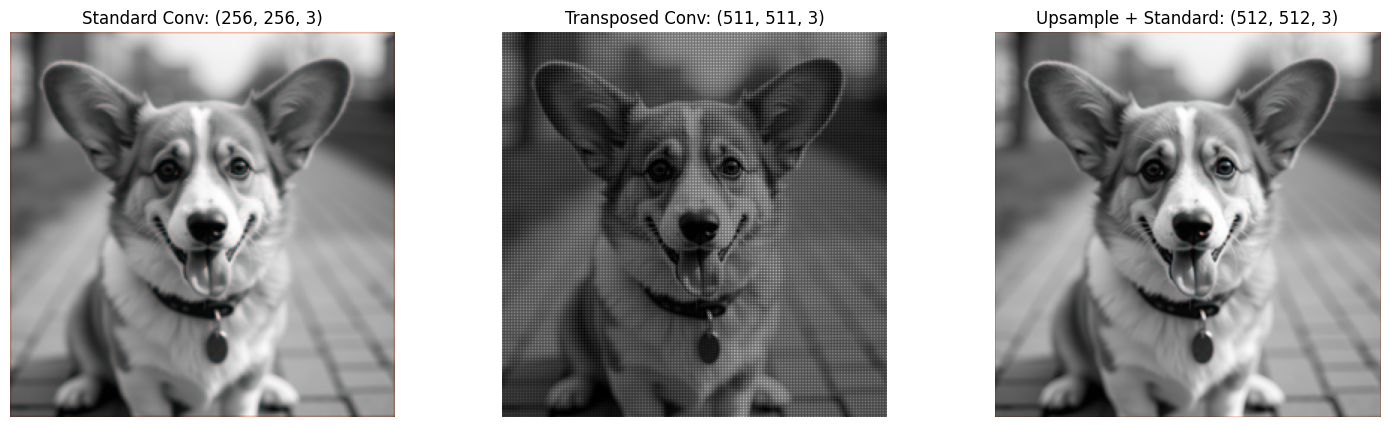

In [11]:
# Transpose  convolution
trans_conv = nn.ConvTranspose2d(3, 3, kernel_size=4, stride=2, padding=1, bias=False)
trans_conv.weight.data = filters_trans
y_transposed = trans_conv(tensor_rgb)

# Upsample + Standard convolution
upsample = nn.Upsample(scale_factor=2, mode='nearest')  # или 'bilinear', align_corners=False
conv_after_upsample = nn.Conv2d(3, 3, 3, padding=1, bias=False)
conv_after_upsample.weight.data = filters_trans
y_upsample_conv = conv_after_upsample(upsample(tensor_rgb))

# Визуализация
trans_vis = np.transpose(normalize(y_transposed[0]), (1,2,0))
std_vis = np.transpose(normalize(y_std[0]), (1, 2, 0))
up_str_vis = np.transpose(normalize(y_upsample_conv[0]), (1, 2, 0))

show_row(
    images=[std_vis, trans_vis, up_str_vis],
    titles=[f"Standard Conv: {std_vis.shape}", f"Transposed Conv: {trans_vis.shape}", f"Upsample + Standard: {up_str_vis.shape}"]
)

## 2. Нормализации

Нормализация активаций — один из ключевых инструментов для **ускорения обучения и стабилизации глубоких сетей**.  


### 1. Основные эффекты нормализации

1. **Снижение Internal Covariate Shift (ICS)**  
   - Активации каждого слоя стандартизируются: среднее ≈ 0, стандартное отклонение ≈ 1  
   - Слои получают **стабильные входы**, обучение быстрее и устойчивее  

2. **Ускорение сходимости**  
   - Стабильные активации позволяют использовать **более высокий learning rate**  
   - Градиенты становятся более предсказуемыми, оптимизация идёт ровнее  

3. **Регуляризация**  
   - Небольшой шум при вычислении статистик по батчу (BatchNorm) действует как **легкая регуляризация**  
   - Снижается риск переобучения  

4. **Смешение распределений / feature mixing**  
   - Нормализация выравнивает распределения активаций, что помогает:  
     - Избавиться от экстремальных значений  
     - Улучшить обучение глубоких сетей  
     - Использоваться в генеративных моделях (StyleGAN, domain adaptation)
  
5. **Универсальность методов**  
   - **BatchNorm**: хорошо для CNN и больших батчей  
   - **LayerNorm**: для RNN и Transformer  
   - **GroupNorm**: для CNN с малым батчем  

### 1. Batch Normalization (BatchNorm)

Нормализуем **каждый признак (feature) по батчу**.  

Пусть входные данные слоя:  

$$
X = [x_1, x_2, \dots, x_m]^T, \quad x_i \in \mathbb{R}^d
$$

где:  
- \(m\) — размер батча  
- \(d\) — число признаков (features)  

**Вычисляем статистики по батчу для каждого признака (j):**

$$
\mu_\text{batch}[j] = \frac{1}{m} \sum_{i=1}^{m} x_{i,j}, \quad
\sigma_\text{batch}^2[j] = \frac{1}{m} \sum_{i=1}^{m} (x_{i,j} - \mu_\text{batch}[j])^2
$$

Нормализуем каждый элемент батча по признаку:

$$
\hat{x}_{i,j} = \frac{x_{i,j} - \mu_\text{batch}[j]}{\sqrt{\sigma_\text{batch}^2[j] + \epsilon}}
$$

Применяем обучаемые параметры $(\gamma_j, \beta_j)$ для восстановления масштаба/сдвига:

$$
y_{i,j} = \gamma_j \hat{x}_{i,j} + \beta_j
$$

**Running statistics для инференса:**

$$
\mu_\text{running}[j] \leftarrow (1 - \text{momentum}) \cdot \mu_\text{running}[j] + \text{momentum} \cdot \mu_\text{batch}[j]
$$

$$
\sigma_\text{running}^2[j] \leftarrow (1 - \text{momentum}) \cdot \sigma_\text{running}^2[j] + \text{momentum} \cdot \sigma_\text{batch}^2[j]
$$

**На инференсе:**

$$
\hat{x}_{i,j}^\text{test} = \frac{x_{i,j} - \mu_\text{running}[j]}{\sqrt{\sigma_\text{running}^2[j] + \epsilon}}, \quad
y_{i,j}^\text{test} = \gamma_j \hat{x}_{i,j}^\text{test} + \beta_j
$$

**Особенности:**
- Усреднение по батчу (ось 0)  
- Каждый признак выравнивается между примерами батча  
- Требует достаточного размера батча для стабильной статистики  

### 2. Layer Normalization (LayerNorm)

Нормализуем **каждый пример по всем признакам**.  

Для примера ($x_i \in \mathbb{R}^d$):

$$
\mu_\text{layer}[i] = \frac{1}{d} \sum_{j=1}^{d} x_{i,j}, \quad
\sigma_\text{layer}^2[i] = \frac{1}{d} \sum_{j=1}^{d} (x_{i,j} - \mu_\text{layer}[i])^2
$$

Нормализуем:

$$
\hat{x}_{i,j} = \frac{x_{i,j} - \mu_\text{layer}[i]}{\sqrt{\sigma_\text{layer}^2[i] + \epsilon}}, \quad
y_{i,j} = \gamma_j \hat{x}_{i,j} + \beta_j
$$

**Особенности:**  
- Независимо от батча  
- Каждый пример нормализован сам по себе  

### 3. Group Normalization (GroupNorm)

Разбиваем каналы на группы (например, в CNN $X \in \mathbb{R}^{N, C, H, W}$) и нормализуем **по каждому блоку каналов**.  

Для канала $c \in \text{группа g}$:

$$
\mu_\text{group}[g] = \frac{1}{m} \sum_{i \in g} x_i, \quad
\sigma_\text{group}^2[g] = \frac{1}{m} \sum_{i \in g} (x_i - \mu_\text{group}[g])^2
$$

Нормализуем:

$$
\hat{x}_i = \frac{x_i - \mu_\text{group}[g]}{\sqrt{\sigma_\text{group}^2[g] + \epsilon}}, \quad
y_i = \gamma_i \hat{x}_i + \beta_i
$$

**Особенности:**  
- Локальная нормализация по группам каналов  
- Работает при малых батчах  
- Смешение идей LayerNorm и BatchNorm  


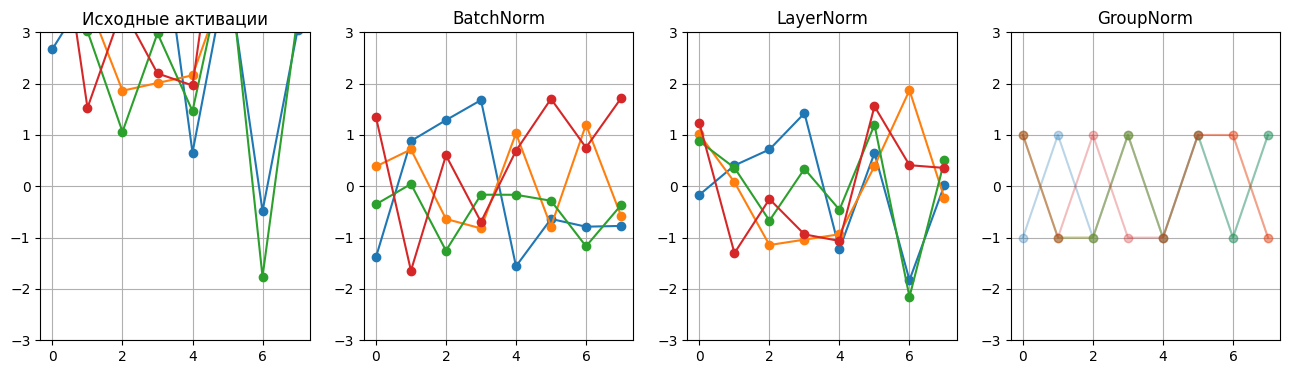

In [12]:
# Случайный батч: 4 примера, 8 признаков
x = torch.randn(4, 8) * 2 + 3

# BatchNorm
bn = nn.BatchNorm1d(8, affine=False)  # без gamma/beta для чистой нормализации
x_bn = bn(x)

# LayerNorm
ln = nn.LayerNorm(8, elementwise_affine=False)
x_ln = ln(x)


# GroupNorm
# Преобразуем x для GroupNorm: (N, C, H, W) = (4, 8, 1, 1)
x_gn_input = x.unsqueeze(-1).unsqueeze(-1)
gn = nn.GroupNorm(num_groups=4, num_channels=8, affine=False)
x_gn = gn(x_gn_input).squeeze(-1).squeeze(-1)

# Визуализация

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
for i in range(4):
    plt.plot(x[i].numpy(), marker='o', label=f'example {i}')
plt.title("Исходные активации")
plt.ylim(-3, 3)
plt.grid(True)

plt.subplot(1,4,2)
for i in range(4):
    plt.plot(x_bn[i].detach().numpy(), marker='o', label=f'example {i}')
plt.title("BatchNorm")
plt.ylim(-3, 3)
plt.grid(True)

plt.subplot(1,4,3)
for i in range(4):
    plt.plot(x_ln[i].detach().numpy(), marker='o', label=f'example {i}')
plt.title("LayerNorm")
plt.ylim(-3, 3)
plt.grid(True)

plt.subplot(1,4,4)
for i in range(4):
    plt.plot(x_gn[i].detach().numpy(), marker='o', label=f'example {i}', alpha=0.3)
plt.title("GroupNorm")
plt.ylim(-3, 3)
plt.grid(True)

plt.show()


### 5*. Смешение распределений через нормализацию (Feature Mixing)


Нормализация может использоваться не только для стабилизации обучения,  
но и как механизм **прокидывания условий** и **смешения признаков**.

Идея: вместо объединения данных — объединяются распределения.


##### 1. Adaptive Normalization (FiLM / AdaNorm)

**Форма:**

$$
h = \text{Norm}(X)
$$

$$
(\gamma(c), \beta(c)) = f(c)
$$

$$
Y = \gamma(c)\cdot h + \beta(c)
$$

**Смысл:**  
условие c управляет масштабом и сдвигом нормализованных признаков.

Используется в:
- AdaIN (StyleGAN)  
- AdaGN (Diffusion Beats GANs)  
- Conditional BN (BigGAN)  
- FiLM layers

##### 2. Cross-Normalization (ControlNeXt)

Пусть:
- $X$ — основной поток (noise / latent)
- $X_{c}$ — conditional поток

Считаем статистики по основному потоку:

$$
\mu = \mathbb{E}[X], \qquad \sigma^2 = \text{Var}(X)
$$

Нормализация condition:

$$
\tilde{X}_{c} = \frac{X_{c} - \mu}{\sqrt{\sigma^2 + \epsilon}}
$$

**Смысл:**  
conditional-поток приводится в распределение основного потока.



## 3. Recap: Dropout

Dropout — это регуляризация, которая случайно “выключает” часть нейронов во время обучения.  
**Цель:** предотвратить переобучение и улучшить обобщение сети


- На каждом прямом проходе каждый нейрон имеет вероятность `p` быть выключенным (зануление).
- Выключенные нейроны не участвуют в вычислении выхода и градиента.
- Во время инференса все нейроны активны, но необходимо адаптировать сигнал (обучались на другом распределении).


$$
\tilde{h} = h \odot m, \quad m_i \sim \text{Bernoulli}(1-p)
$$


**Реализация Dropout в PyTorch**

- Во время обучения: значение нейронов масштабируется на `1/(1-p)`, градиенты выключенных нейронов = 0:

    $$
    \tilde{h}_i = \frac{h_i \cdot m_i}{1-p}
    $$
- Во время инференса (`model.eval()`):
  - Все нейроны активны.
  - Масштабирование не требуется.


## 4. Инициализации весов

Инициализация влияет на:
- динамику градиентов,
- стабильность обучения,
- скорость сходимости,
- геометрию оптимизационного ландшафта.

Неправильная инициализация приводит к:
- vanishing / exploding gradients,
- симметрии нейронов,
- плохой сходимости,
- плоским областям лосса.


#### Нулевая инициализация (Zero Initialization)

$$
W_{i,j} = 0
$$

**Проблема (Symmetry Problem)**:
- все нейроны получают одинаковые входы,
- вычисляют одинаковые выходы,
- градиенты одинаковы,
- веса остаются одинаковыми → сеть деградирует


#### Случайная инициализация (Naive Random Init)

$$
W_{i,j} \sim \mathcal{N}(0, \sigma^2) \quad \text{или} \quad \mathcal{U}(-a, a)
$$

**Проблема:** при глубине сети $Var(h_l) ~ prod Var(W_k)$
- Vanishing gradients: $Var(W) < 1 → Var(h_l) → 0$
- Exploding gradients: $Var(W) > 1 → Var(h_l) → ∞$

#### 2. Xavier / Glorot Initialization

Для tanh / sigmoid:

$$
W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)
$$

**Идея:** сохранить дисперсию активаций и градиентов  
стабильные градиенты, хорошая сходимость


#### 3. He / Kaiming Initialization

Для ReLU:

$$
W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)
$$

**Почему:** ReLU обнуляет ~50% активаций → нужна компенсация дисперсии  


#### 4. Orthogonal Initialization

$$
W^T W = I
$$

**Свойства:**
- сохраняет длину и углы векторов,
- минимальные искажения геометрии,
- стабильные градиенты.

---

#### Итоговая таблица

| Инициализация | Когда использовать | Особенности |
|---------------|-----------------|-------------|
| Zero | - | Симметрия → нестабильное обучение |
| Random | простые эксперименты | Vanishing / Exploding |
| Xavier | tanh / sigmoid | Стабильные градиенты  |
| He | ReLU / LeakyReLU | Компенсация дисперсии  |
| Orthogonal | глубокие слои | Сохраняет геометрию |


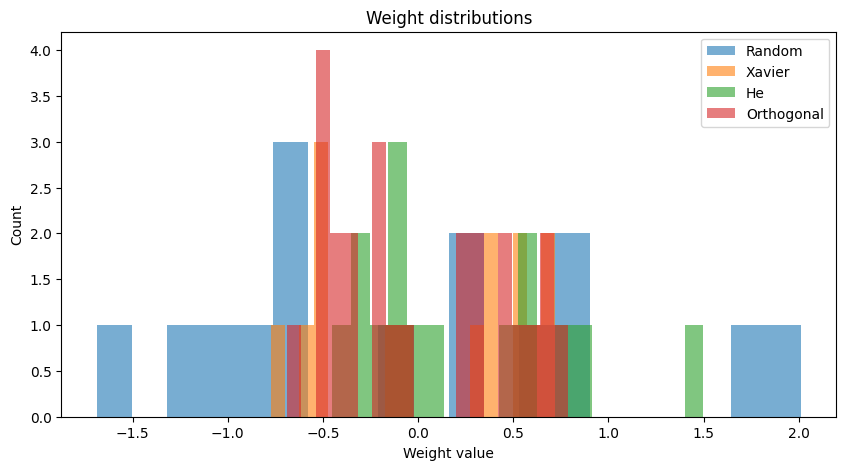

In [13]:
# Zero Initialization
zero_layer = nn.Linear(5,3)
nn.init.constant_(zero_layer.weight, 0.0)

# Random Initialization
rand_layer = nn.Linear(5,3)
nn.init.normal_(rand_layer.weight, mean=0.0, std=1.0)

# Xavier Initialization
xavier_layer = nn.Linear(5,3)
nn.init.xavier_uniform_(xavier_layer.weight)

# He Initialization
he_layer = nn.Linear(5,3)
nn.init.kaiming_normal_(he_layer.weight, nonlinearity='relu')

# Orthogonal Initialization (square layer)
ortho_layer = nn.Linear(5,5)
nn.init.orthogonal_(ortho_layer.weight)

layers = [rand_layer, xavier_layer, he_layer, ortho_layer]
labels = ["Random", "Xavier", "He", "Orthogonal"]

plt.figure(figsize=(10,5))
for layer, label in zip(layers, labels):
    plt.hist(layer.weight.detach().numpy().flatten(), bins=20, alpha=0.6, label=label)
plt.title("Weight distributions")
plt.xlabel("Weight value")
plt.ylabel("Count")
plt.legend()
plt.show()